# Part 4: Bacteria and Nutrients 

Topics covered in part 4 include:
- dataframe manipulation: mutate, select, inner_join, pivot_longer 
- group_by and summarize
- another application of ifelse function 
- more visualization with ggplot 

In [40]:
# load necessary libraries
library(tidyverse)
library(lubridate)
library(janitor)
# make plots larger
options(repr.plot.width = 12, repr.plot.height = 8)

## Summarize nutrient and bacteria data 

In [13]:

## read in data and check for missing data
# the document needs to be a CSV, so change the file format in Excel
bact <- read.csv("K-avi_Bacteria_and_Nutrient_Data.csv")

# look at the structure of the file, see what might need to be changed
str(bact)


'data.frame':	557 obs. of  10 variables:
 $ X                        : int  1 2 3 4 5 6 7 8 9 10 ...
 $ sample_location          : chr  "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" ...
 $ longitude                : chr  "51.47.40 N" "51.47.40 N" "51.47.40 N" "51.47.40 N" ...
 $ latitude                 : chr  "117.25.31 W" "117.25.31 W" "117.25.31 W" "117.25.31 W" ...
 $ date                     : chr  "1/15/90" "2/1/90" "3/15/90" "4/12/90" ...
 $ E.coli.col.100.mL        : int  NA NA NA NA NA 151 152 152 NA NA ...
 $ Total.Coliform.col.100.mL: int  NA NA NA NA NA 322 330 300 NA NA ...
 $ Nitrates.mg.L            : num  NA NA NA NA NA 14.9 15.2 15 NA NA ...
 $ mg.L                     : num  NA NA NA NA NA 0.14 0.15 0.13 NA NA ...
 $ Turbidity.ntu            : int  NA NA NA NA NA 41 43 42 NA NA ...


In [18]:
# most data were formatted correctly, we just have to fix problems with the date
bact$date <- as.Date(bact$date, format = "%m/%d/%y")

# create a column that's specific to the year
bact$year <- year(bact$date)

# rerun the structure function, to know that it worked
str(bact)

# clean headers 
colnames(bact) <- tolower(colnames(bact))

'data.frame':	557 obs. of  11 variables:
 $ x                        : int  1 2 3 4 5 6 7 8 9 10 ...
 $ sample_location          : chr  "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" "Monitoring Site 1" ...
 $ longitude                : chr  "51.47.40 N" "51.47.40 N" "51.47.40 N" "51.47.40 N" ...
 $ latitude                 : chr  "117.25.31 W" "117.25.31 W" "117.25.31 W" "117.25.31 W" ...
 $ date                     : Date, format: "1990-01-15" "1990-02-01" ...
 $ e.coli.col.100.ml        : int  NA NA NA NA NA 151 152 152 NA NA ...
 $ total.coliform.col.100.ml: int  NA NA NA NA NA 322 330 300 NA NA ...
 $ nitrates.mg.l            : num  NA NA NA NA NA 14.9 15.2 15 NA NA ...
 $ mg.l                     : num  NA NA NA NA NA 0.14 0.15 0.13 NA NA ...
 $ turbidity.ntu            : int  NA NA NA NA NA 41 43 42 NA NA ...
 $ year                     : num  1990 1990 1990 1990 1990 1990 1990 1990 1990 1990 ...


,x,sample_location,longitude,latitude,date,e.coli.col.100.ml,total.coliform.col.100.ml,nitrates.mg.l,mg.l,turbidity.ntu,year
,<int>,<chr>,<chr>,<chr>,<date>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>
1,1,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-01-15,NA,NA,NA,NA,NA,1990
2,2,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-02-01,NA,NA,NA,NA,NA,1990
3,3,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-03-15,NA,NA,NA,NA,NA,1990
4,4,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-04-12,NA,NA,NA,NA,NA,1990
5,5,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-05-11,NA,NA,NA,NA,NA,1990
6,6,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-06-15,151,322,14.9,0.14,41,1990


In [22]:
## now we can start summarizing the data, we'll look at it on an annual level
bact_sum <- bact %>%
  group_by(sample_location, year) %>% # you can group by multiple or a single group(s) to make this summary
  summarize_at(vars(e.coli.col.100.ml, total.coliform.col.100.ml, mg.l, turbidity.ntu),
               list(mean=mean, median=median, min=min, max=max), na.rm=T)

head(bact_sum)

Warning message:
"There were 40 warnings in `summarise()`.
The first warning was:
ℹ In argument: `e.coli.col.100.ml_min = .Primitive("min")(e.coli.col.100.ml, na.rm = TRUE)`.
ℹ In group 17: `sample_location = "Monitoring Site 2"` `year = 1995`.
Caused by warning:
! no non-missing arguments to min; returning Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 39 remaining warnings."


sample_location,year,e.coli.col.100.ml_mean,total.coliform.col.100.ml_mean,mg.l_mean,turbidity.ntu_mean,e.coli.col.100.ml_median,total.coliform.col.100.ml_median,mg.l_median,turbidity.ntu_median,e.coli.col.100.ml_min,total.coliform.col.100.ml_min,mg.l_min,turbidity.ntu_min,e.coli.col.100.ml_max,total.coliform.col.100.ml_max,mg.l_max,turbidity.ntu_max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Monitoring Site 1,1990,151.6667,317.3333,0.1400000,42.00000,152,322,0.140,42,151,300,0.13,41,152,330,0.15,43
Monitoring Site 1,1991,151.6667,317.3333,0.1400000,42.00000,152,322,0.140,42,151,300,0.13,41,152,330,0.15,43
Monitoring Site 1,1992,153.0000,317.3333,0.1583333,43.33333,153,321,0.155,43,152,299,0.15,42,154,332,0.17,45
Monitoring Site 1,1993,153.0000,317.3333,0.1583333,43.33333,153,321,0.155,43,152,299,0.15,42,154,332,0.17,45
Monitoring Site 1,1994,149.3333,285.6667,0.1233333,39.33333,149,285,0.120,39,148,273,0.10,39,151,299,0.15,40
Monitoring Site 1,1995,149.3333,285.6667,0.1233333,39.33333,149,285,0.120,39,148,273,0.10,39,151,299,0.15,40


bind to existing water quality dataset 

In [26]:
# read in cleaned water quality dataset
water <- read.csv("K-avi_tribe_water_quality_dataset_clean.csv")

# remove the line number (X), column
water <- water[,-1]

# we're going to bind the two datasets together using a function in tidyverse
# full_join() is much more reliable & versitle function than merge(),
# which is a base R function
# join <- full_join(water, bact)


Joining with `by = join_by(sample_location, longitude, latitude, date, year)`


ERROR: [1m[33mError[39m in `full_join()`:[22m
[1m[22m[33m![39m Can't join `x$date` with `y$date` due to incompatible types.
[36mℹ[39m `x$date` is a <character>.
[36mℹ[39m `y$date` is a <date>.


fix error - incompatible types - explain how an error would occur if you skip this step 

note that date is stored as a character in one data frame and as a date in another - to join, these need to be the same 

In [29]:
water$date <- ymd(water$date)
# now we can try again to join them
join <- full_join(water, bact) # success
# this function is great, because it is telling us all the information it is joining by!

head(join)

Joining with `by = join_by(sample_location, longitude, latitude, date, year)`


,sample_location,longitude,latitude,date,DO,water_temp_C,water_temp_F,specific_conductivity,discharge,year,x,e.coli.col.100.ml,total.coliform.col.100.ml,nitrates.mg.l,mg.l,turbidity.ntu
,<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<int>
1,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-01-15,12.3,0.3,32.54,80,35,1990,1,NA,NA,NA,NA,NA
2,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-02-01,12.3,0.4,NA,82,27,1990,2,NA,NA,NA,NA,NA
3,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-03-15,12.3,0.4,NA,93,20,1990,3,NA,NA,NA,NA,NA
4,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-04-12,11.9,0.5,NA,85,26,1990,4,NA,NA,NA,NA,NA
5,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-05-11,11.8,4.0,NA,110,100,1990,5,NA,NA,NA,NA,NA
6,Monitoring Site 1,51.47.40 N,117.25.31 W,1990-06-15,10.9,5.9,NA,180,261,1990,6,151,322,14.9,0.14,41


## Join to TEK summary dataset ####


In [33]:
# read in the TEK summary dataset so we know what we're working with
tek_sum <- read.csv("tek_summary.csv")

# it can be helpful to know what our column names are when we're summarizing
# data, so try this to have a list
names(join)

# now we need to summarize the water quality dataset so that we can have them
# in the same format to merge them together
join_sum <- join %>%
  group_by(sample_location) %>%
  # find the mean for all of the different water quality metrics
  summarise(mean_DO = mean(DO),
            mean_temp = mean(water_temp_C),
            mean_sc = mean(specific_conductivity),
            mean_ecoli = mean(e.coli.col.100.ml, na.rm = T),
            mean_tot_col = mean(total.coliform.col.100.ml, na.rm = T),
            mean_nit = mean(nitrates.mg.l, na.rm = T),
            mean_phos = mean(mg.l, na.rm = T),
            mean_turb = mean(turbidity.ntu, na.rm = T))


all_data <- inner_join(join_sum, tek_sum)

[1] "sample_location"           "longitude"                
 [3] "latitude"                  "date"                     
 [5] "DO"                        "water_temp_C"             
 [7] "water_temp_F"              "specific_conductivity"    
 [9] "discharge"                 "year"                     
[11] "x"                         "e.coli.col.100.ml"        
[13] "total.coliform.col.100.ml" "nitrates.mg.l"            
[15] "mg.l"                      "turbidity.ntu"

Joining with `by = join_by(sample_location)`


how might we want to visualize this combined dataframe?
  
##  Nutrient data failure calculations


 here we can review the ifelse() function 
 the format is ifelse(condition, value if true, value if false) 

 pipe the water quality data - you can either use the bact dataframe or join
 I am just going to work with bact to make sure sure we're working with less data

We use the `mutate()` function to create new columns (one for each water quality metric), that checks if the metric for each measurement date pases or fails based on the K'avi water quality standards, where 1 = pass, 0 = fail

In [35]:
bact_check <- bact %>%
  mutate(ecoli_check = if_else(e.coli.col.100.ml >= 126, 1, 0),
         tot_col_check = if_else(total.coliform.col.100.ml >= 250, 1, 0),
         nit_check = if_else(nitrates.mg.l >= 10, 1, 0),
         phos_check = if_else(mg.l >= 0.07, 1, 0))

Now that we know when each standard passes / fails, we can count them to
figure out how often each sampling location fails based on each measurement
so, pipe our water quality data

In [36]:
rank_sum <- bact_check %>%
  # remove all the NA rows by filtering for only the rows that have a 1 or 0
  filter(ecoli_check == 1 | ecoli_check == 0) %>%
  # group the data by the sampling location
  group_by(sample_location) %>%
  # summarize the data
  # get the length (number of samples collected at each site)
  summarise(n_sample = length(ecoli_check),
            # find the number of times the ecoli measurement failed to meet the K'avi standards
            ecoli_fail = length(which(ecoli_check == 0)),
            # calculate the % failure rate for ecoli measurements / site
            ecoli_percent = ecoli_fail / n_sample * 100,
            # find the number of times the total coliform failed to meet the K'avi standards
            tot_col_fail = length(which(tot_col_check == 0)),
            # calculate the % failure rate for total coliform  measurements / site
            tot_col_percent = tot_col_fail / n_sample * 100,
            # find the number of times the nitrate measurement
            # failed to meet the K'avi standards
            nit_fail = length(which(nit_check == 0)),
            # calculate the % failure rate for nitrate measurements / site
            nit_percent = nit_fail / n_sample * 100,
            #find the number of times the phosphorous levels failed to meet the standards
            phos_fail = length(which(phos_check == 0)),
            # calculate the % failure rate for phosphorous measurements / site
            phos_percent = phos_fail / n_sample * 100,
            # calculate the average failure rate for each site across all water
            # quality measurements
            average_fail = mean(c(ecoli_percent, tot_col_percent, nit_percent, phos_percent))
  )

## Visualize 

Joining with `by = join_by(sample_location)`


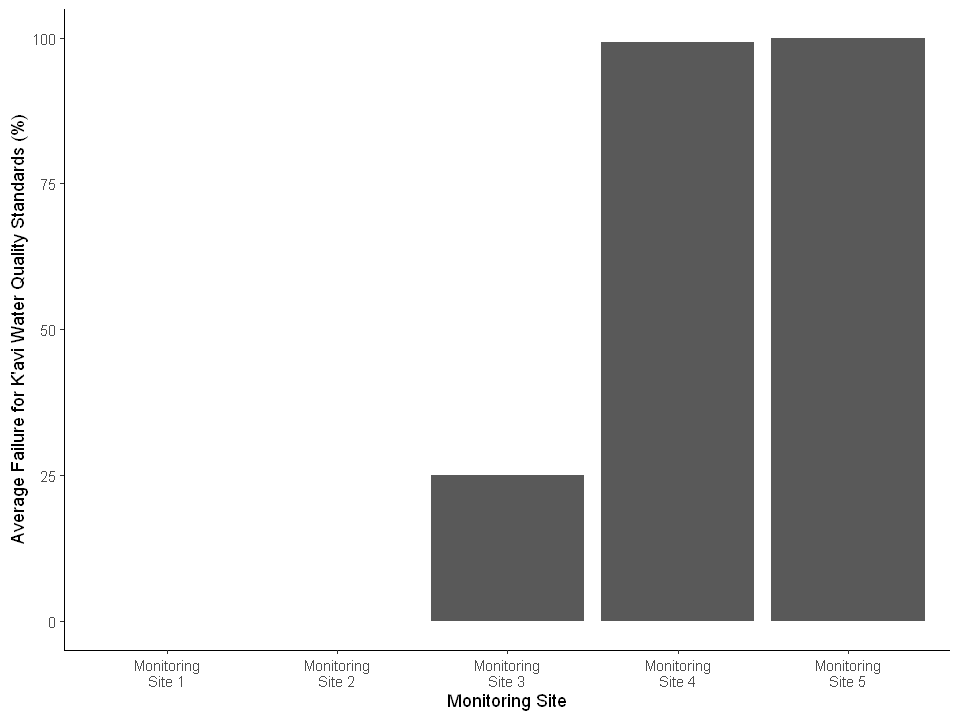

Joining with `by = join_by(sample_location)`


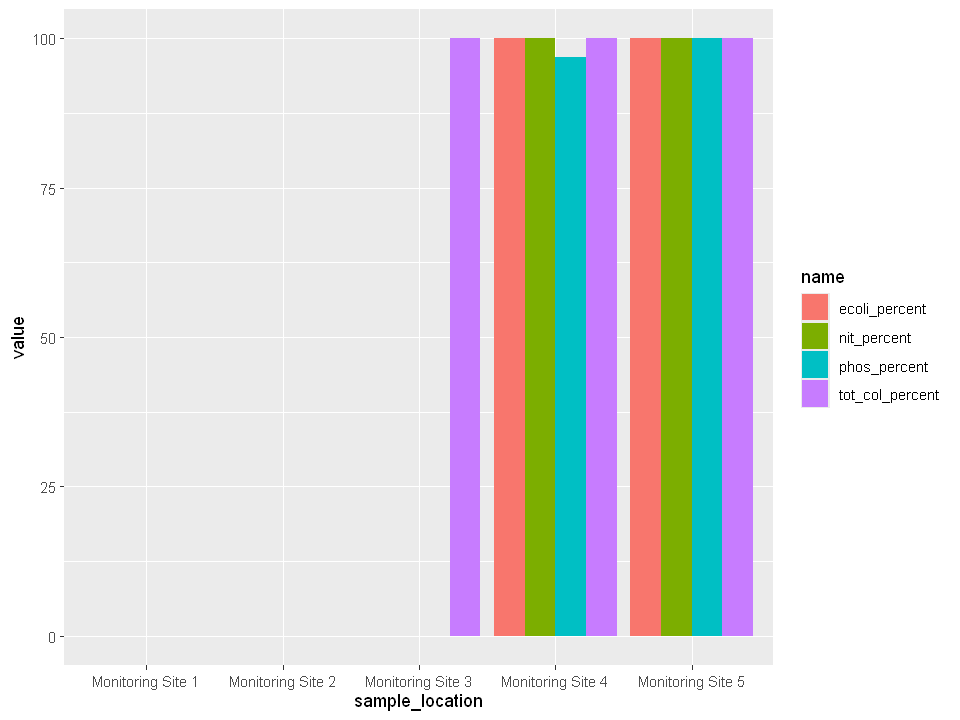

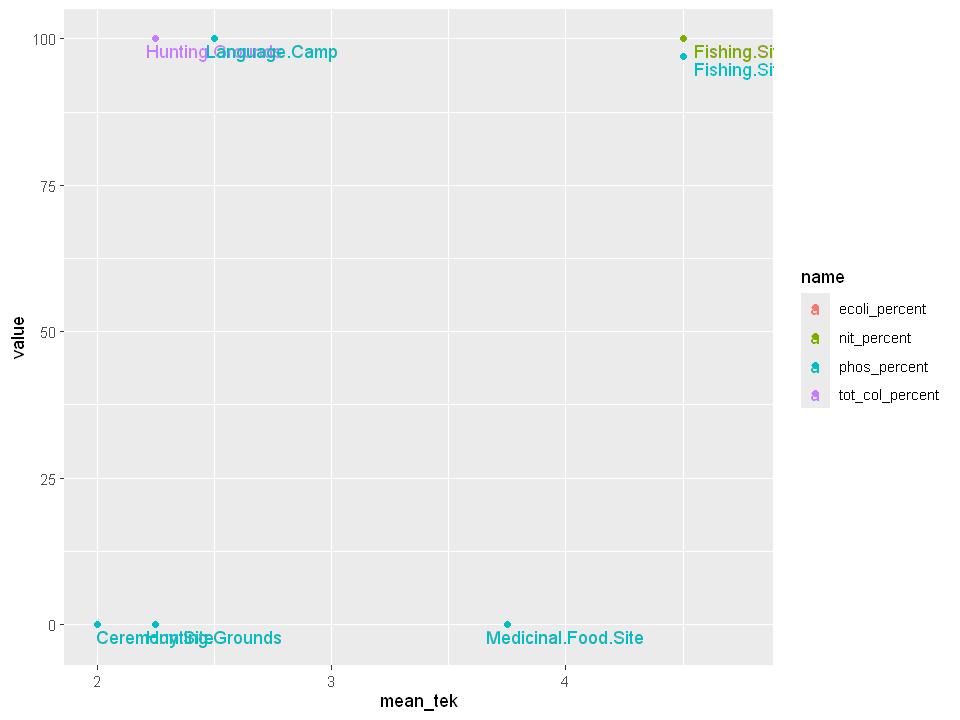

In [41]:
## visualize the data
rank_sum %>%
  ggplot(aes(x = sample_location, y = average_fail)) +
  geom_col() +
  xlab("Monitoring Site") +
  ylab("Average Failure for K'avi Water Quality Standards (%)") +
  # wrap the monitoring site names so that the text doesn't overlap
  scale_x_discrete(labels = function(x) str_wrap(x, width = 10)) +
  theme_classic()

## visualize each location percent by water quality measure
rank_sum %>% 
  inner_join(tek_sum) %>% 
  select(sample_location, mean_tek, site, ecoli_percent, tot_col_percent, nit_percent, phos_percent, sample_location) %>% 
  pivot_longer(c(ecoli_percent, tot_col_percent, nit_percent, phos_percent)) %>% 
  ggplot(aes(x=sample_location, y=value, fill=name)) + 
  geom_col(position='dodge')

rank_sum %>% 
  inner_join(tek_sum) %>% 
  select(sample_location, mean_tek, site, ecoli_percent, tot_col_percent, nit_percent, phos_percent, sample_location) %>% 
  pivot_longer(c(ecoli_percent, tot_col_percent, nit_percent, phos_percent)) %>% 
  ggplot(aes(x=mean_tek, y=value, col=name)) +
  geom_point() +
  geom_text(aes(label=site), nudge_x = .25, nudge_y = -2)
